In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')  # Ignore all warnings
df = pd.read_csv("/content/Food_Delivery_Times.csv")
df.head(10)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,NaN,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73


In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore only convergence warnings from sklearn
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Ignore FutureWarnings (common in pandas/sklearn)
warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
df.shape

(1000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [ ]:
# View column types
print(df.dtypes)

Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(df.isnull().sum())

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [ ]:
# Finding total no. of null values
df.isnull().sum().sum()

np.int64(120)

In [ ]:
# #Here convert those columns (Change String to Integer format)
# categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

# for col in categorical_cols:
#     df[col] = df[col].astype('category')
# df[col]

In [ ]:
data_1 = df.fillna('Unknown') # Fill an null values
data_1

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [ ]:
data_1.head(50)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,Unknown,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73


In [ ]:
df = data_1
df.head(20)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,Unknown,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73


In [ ]:
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for col in categorical_cols:
    df[col] = df[col].astype('category')

print(df['Traffic_Level'].unique())
print()
print(df['Weather'].unique())
print()
print(df['Vehicle_Type'].unique())
print()
print(df['Time_of_Day'].unique())

['Low', 'Medium', 'High', 'Unknown']
Categories (4, object): ['High', 'Low', 'Medium', 'Unknown']

['Windy', 'Clear', 'Foggy', 'Rainy', 'Snowy', 'Unknown']
Categories (6, object): ['Clear', 'Foggy', 'Rainy', 'Snowy', 'Unknown', 'Windy']

['Scooter', 'Bike', 'Car']
Categories (3, object): ['Bike', 'Car', 'Scooter']

['Afternoon', 'Evening', 'Night', 'Morning', 'Unknown']
Categories (5, object): ['Afternoon', 'Evening', 'Morning', 'Night', 'Unknown']


In [ ]:
print(df['Traffic_Level'].value_counts())
print()
print(df['Weather'].value_counts())
print()
print(df['Vehicle_Type'].value_counts())
print()
print(df['Time_of_Day'].value_counts())

Traffic_Level
Medium     390
Low        383
High       197
Unknown     30
Name: count, dtype: int64

Weather
Clear      470
Rainy      204
Foggy      103
Snowy       97
Windy       96
Unknown     30
Name: count, dtype: int64

Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64

Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
Unknown       30
Name: count, dtype: int64


In [ ]:
df['Weather'] = df['Weather'].replace({'Unknown':'Fair'})
df['Traffic_Level'] = df['Traffic_Level'].replace({'Unknown':'Medium'})
df['Time_of_Day'] = df['Time_of_Day'].replace({'Unknown':'Morning'})
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].replace({'Unknown':'0.0'})
df.head(30)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,Morning,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [ ]:
#Eliminate those data that's more then or equal 1 hour:--
df = df[df['Delivery_Time_min'] <= 60]
df.head(30)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,Morning,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
12,637,10.89,Clear,High,Night,Bike,12,5.0,53
13,974,4.69,Rainy,Medium,Evening,Scooter,12,7.0,36
14,939,2.80,Clear,High,Morning,Scooter,10,0.0,33


In [ ]:
df.shape

(585, 9)

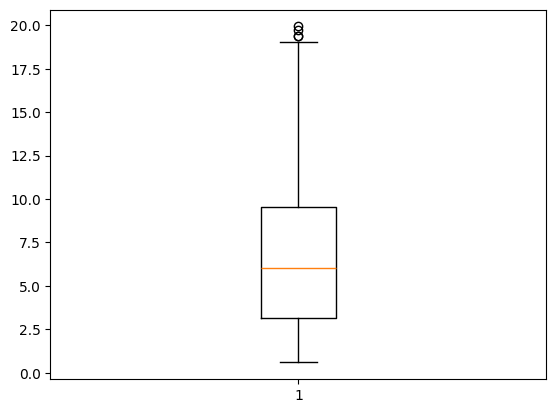

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(df['Distance_km'])
plt.show()

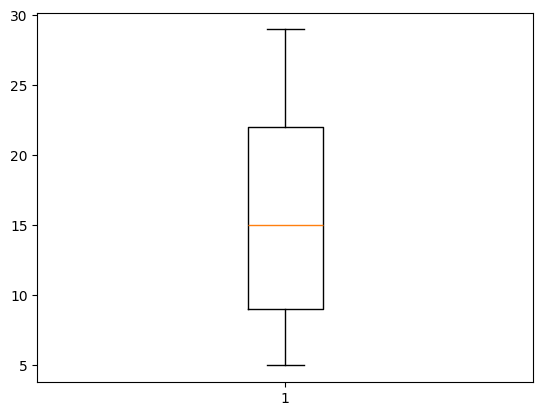

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(df['Preparation_Time_min'])
plt.show()

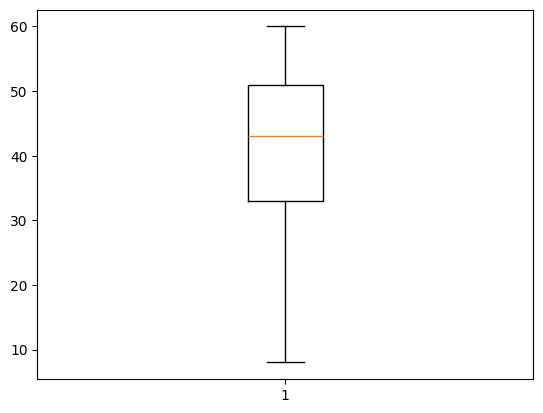

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(df['Delivery_Time_min'])
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer # Import SimpleImputer
from sklearn.model_selection import train_test_split # Import train_test_split

# Assuming 'df' is your DataFrame after handling outliers
# If you need to reload or re-apply previous steps, you can uncomment the following:
df = pd.read_csv("/content/Food_Delivery_Times.csv")
df = df[df['Delivery_Time_min'] <= 60].copy() # Based on your previous filtering, ensure we are working on a copy

# Replace 'Unknown' values in categorical and numerical columns before processing
# For categorical columns, fill with a placeholder like 'Unknown' for now
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    df[col] = df[col].fillna('Unknown')

# Replace 'Unknown' in 'Courier_Experience_yrs' with a numeric value (e.g., 0.0)
# And fill any remaining NaNs in this column with the mean if necessary, although filling 'Unknown' first helps
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].replace('Unknown', 0.0).astype(float)
# Handle any other potential numerical NaNs
for col in ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())


# Drop 'Order_ID' column as it's not a feature for the model
df = df.drop('Order_ID', axis=1)

# Define features (X) and target (y)
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=np.number).columns


# Preprocessing steps
# Use OrdinalEncoder for categorical features to handle 'Unknown' and other categories
# Use StandardScaler for numerical features
preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
    ('num', Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), numerical_cols) # Add SimpleImputer for numerical columns
], remainder='passthrough') # Keep other columns (like Order_ID) if needed, or drop with 'drop'

# Apply the preprocessing to the entire dataset
X_processed = preprocessor.fit_transform(X)


print("Preprocessing complete. The data is now ready for a machine learning model.")

Preprocessing complete. The data is now ready for a machine learning model.


In [ ]:
# Fill NaN values with median (or mean, or a fixed value)
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

# Convert to integer
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].astype(int)
df.head(30)


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1,43
2,9.52,Foggy,Low,Night,Scooter,28,1,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1,37
5,19.40,Clear,Low,Evening,Scooter,8,9,57
6,9.52,Clear,Low,Unknown,Bike,12,1,49
7,17.39,Clear,Medium,Evening,Scooter,5,6,46
8,1.78,Snowy,Low,Evening,Car,20,6,35
12,10.89,Clear,High,Night,Bike,12,5,53
13,4.69,Rainy,Medium,Evening,Scooter,12,7,36
14,2.80,Clear,High,Morning,Scooter,10,4,33


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Distance_km']=le.fit_transform(df['Distance_km'])
df['Weather']=le.fit_transform(df['Weather'])
df['Traffic_Level']=le.fit_transform(df['Traffic_Level'])
df['Time_of_Day']=le.fit_transform(df['Time_of_Day'])
df['Vehicle_Type']=le.fit_transform(df['Vehicle_Type'])
df['Courier_Experience_yrs']=le.fit_transform(df['Courier_Experience_yrs'])
df.head(30)

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,303,5,1,0,2,12,1,43
2,350,1,1,3,2,28,1,59
3,279,2,2,0,2,5,1,37
5,481,0,1,1,2,8,9,57
6,350,0,1,4,0,12,1,49
7,473,0,2,1,2,5,6,46
8,52,3,1,1,1,20,6,35
12,389,0,0,3,0,12,5,53
13,179,2,2,1,2,12,7,36
14,101,0,0,2,2,10,4,33


In [ ]:
x = df.drop(columns=['Delivery_Time_min'])  # Input
y = df['Delivery_Time_min']                 # Output
y

,Delivery_Time_min
0,43
2,59
3,37
5,57
6,49
...,...
993,58
994,25
995,54
998,55


In [ ]:
df.isnull().sum()

,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
x = mm.fit_transform(x)
x

array([[0.62603306, 1.        , 0.33333333, ..., 1.        , 0.29166667,
        0.11111111],
       [0.7231405 , 0.2       , 0.33333333, ..., 1.        , 0.95833333,
        0.11111111],
       [0.57644628, 0.4       , 0.66666667, ..., 1.        , 0.        ,
        0.11111111],
       ...,
       [0.66528926, 0.        , 0.        , ..., 0.5       , 0.33333333,
        0.33333333],
       [0.93801653, 0.        , 0.33333333, ..., 0.        , 0.125     ,
        0.        ],
       [0.50826446, 0.2       , 0.33333333, ..., 1.        , 0.79166667,
        0.33333333]])

In [ ]:
from sklearn.model_selection import train_test_split
X_train_processed, X_test_processed, ytrain, ytest = train_test_split(X_processed, y, test_size=0.2, random_state=23)
X_train_processed

array([[ 2.        ,  2.        ,  2.        , ...,  0.25531219,
        -0.66628597,  0.        ],
       [ 2.        ,  1.        ,  1.        , ...,  3.09534276,
        -0.80812632, -0.96755954],
       [ 0.        ,  2.        ,  1.        , ...,  2.27272956,
        -1.37548773, -1.6769361 ],
       ...,
       [ 2.        ,  1.        ,  3.        , ..., -1.07935993,
         1.03579827, -0.96755954],
       [ 0.        ,  1.        ,  2.        , ..., -0.26385867,
        -0.80812632,  1.16057013],
       [ 2.        ,  0.        ,  2.        , ..., -0.39898533,
         0.75211756, -1.6769361 ]])

In [ ]:
y

,Delivery_Time_min
0,43
2,59
3,37
5,57
6,49
...,...
993,58
994,25
995,54
998,55


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
# Use the preprocessor pipeline before training the model
# knn_pipeline = Pipeline([
#     ('preprocessor', preprocessor), # Use the preprocessor defined in cell 2d84af5b
#     ('knn', KNeighborsClassifier())
# ])

# Train the model
knn = KNeighborsClassifier()
knn.fit(X_train_processed, ytrain)

# Make predictions
predict = knn.predict(X_test_processed)
predict

array([17, 38, 48, 57, 47, 30, 25, 23, 27, 32, 28, 27, 30, 27, 49, 36, 33,
       17, 31, 35, 37, 44, 48, 30, 20,  8, 43, 33, 24, 47, 39, 41, 36, 32,
       20, 41, 28, 23, 32, 24, 21, 29, 31, 36, 23, 38, 42, 48, 49, 57, 23,
       33, 35, 48, 44, 30, 42, 21, 51, 23, 23, 35, 32, 31, 36, 28, 42, 31,
       41, 17, 28, 21, 36, 51, 37, 24, 32, 36, 40, 31, 39, 31, 41, 48, 21,
       39, 19, 27, 27, 29, 56, 17, 19, 43, 31, 41, 21, 34, 32, 32, 49, 30,
       32, 44, 57, 51, 17, 21, 58, 32, 26, 34, 43, 44, 34, 29, 24])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest,predict)

0.03418803418803419

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import numpy as np

# Handle missing values (already done by the preprocessor)
# imputer = SimpleImputer(strategy='mean')  # You can also use 'median' or 'most_frequent')
# xtrain = imputer.fit_transform(xtrain)
# xtest = imputer.transform(xtest)

# Create and train model
lr = LogisticRegression(max_iter=1000)  # Increased iterations to ensure convergence
lr.fit(X_train_processed, ytrain)

# Predict
predict_1 = lr.predict(X_test_processed)
print(predict_1)

[27 51 44 57 51 30 30 38 45 34 38 37 43 42 56 44 49 28 53 51 37 44 51 51
 35 28 57 53 27 51 42 59 58 38 30 53 37 27 32 27 35 56 48 44 26 49 58 60
 49 51 37 37 37 43 44 28 57 17 57 30 34 56 37 51 49 14 60 42 57 32 14 44
 37 51 37 16 48 49 59 51 58 57 57 42 34 58 27 58 28 51 42 17 27 57 48 51
 31 57 30 30 49 26 44 58 57 51 21 33 58 37 33 38 56 44 37 32 34]


In [ ]:
#Accuracy Score:--
from sklearn.metrics import accuracy_score
accuracy_score(ytest,predict_1)

0.06837606837606838

In [ ]:
from sklearn.neural_network import MLPClassifier
# Create a model:-
model = MLPClassifier(solver = 'adam',hidden_layer_sizes=(5,2),random_state=2, max_iter=2000)
# Train the model:-
model.fit(X_train_processed, ytrain)
# Predict:-
predict_2 = model.predict(X_test_processed)
predict_2

array([28, 57, 57, 57, 49, 28, 17, 28, 37, 50, 43, 49, 43, 43, 57, 43, 48,
       28, 58, 57, 43, 44, 49, 49, 35, 17, 51, 57, 37, 49, 49, 57, 51, 44,
       28, 57, 43, 35, 28, 28, 32, 51, 57, 51, 37, 49, 57, 57, 51, 57, 37,
       43, 28, 43, 51, 30, 57, 17, 57, 35, 28, 58, 37, 44, 49, 28, 57, 49,
       57, 35, 28, 43, 37, 57, 37, 28, 57, 57, 57, 51, 57, 57, 57, 37, 28,
       57, 17, 57, 17, 49, 51, 17, 17, 57, 51, 51, 35, 57, 28, 36, 51, 28,
       51, 57, 57, 57, 21, 32, 57, 36, 35, 37, 57, 43, 43, 28, 28])

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Load Dataset
df = pd.read_csv("Food_Delivery_Times.csv")

# Optional: Filter rows if needed
df = df[df["Delivery_Time_min"] <= 60]

# Separate features and target
x = df.drop("Delivery_Time_min", axis=1)
y = df["Delivery_Time_min"]

# Identify column types
categorical_cols = x.select_dtypes(include=["object"]).columns
numerical_cols = x.select_dtypes(exclude=["object"]).columns

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train-test split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

# Train model
pipeline.fit(xtrain, ytrain)

# Predict and Evaluate
ypred = pipeline.predict(xtest)
print("MAE:", mean_absolute_error(ytest, ypred))
print("RMSE:", np.sqrt(mean_squared_error(ytest, ypred)))
print("R2 Score:", r2_score(ytest, ypred))


MAE: 3.957094017094017
RMSE: 4.934653226837303
R2 Score: 0.8330272089931585


In [ ]:
#Accuracy Score:--
from sklearn.metrics import accuracy_score
accuracy_score(ytest,predict_2)

0.03418803418803419

In [ ]:
df['Experience_Level'] = pd.cut(df['Courier_Experience_yrs'],
                                bins=[0, 2, 5, 100],
                                labels=['Beginner', 'Intermediate', 'Expert'])


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# Apply the preprocessing pipeline to the data
x_processed = preprocessor.transform(x)

scores = cross_val_score(RandomForestRegressor(), x_processed, y, cv=5, scoring='r2')
print("CV Mean Score:", scores.mean())

CV Mean Score: 0.811114798785745


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rnd = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=23),
    param_distributions=param_dist,
    n_iter=10,   # only test 10 random combinations
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=23
)
rnd.fit(X_train_processed, ytrain)

print("Best Params:", rnd.best_params_)
print("Best Score:", rnd.best_score_)

Best Params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}
Best Score: -0.03162432724442913


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # Ignore warnings

# Expanded parameter space
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']  # Added
}

rnd = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=23),
    param_distributions=param_dist,
    n_iter=20,              # Increased for better search
    cv=3,
    scoring='r2',
    n_jobs=-1,              # Faster by using all cores
    random_state=23,
    verbose=1               # Show progress
)

rnd.fit(X_train_processed, ytrain)

print("Best Params:", rnd.best_params_)
print("Best Score:", rnd.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}
Best Score: -0.012215642060108611


In [ ]:
# Train final model with best params
best_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    random_state=23
)
best_model.fit(X_train_processed, ytrain)

# Evaluate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = best_model.predict(X_test_processed)

print("Test R2 Score:", r2_score(ytest, y_pred))
print("MAE:", mean_absolute_error(ytest, y_pred))
print("MSE:", mean_squared_error(ytest, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(ytest, y_pred)))

Test R2 Score: -0.1501384478351373
MAE: 10.819574964387463
MSE: 167.73268259164658
RMSE: 12.95116529859945


In [ ]:
# ----------------------------
# Step 1: Import libraries
# ----------------------------
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import pandas as pd
from sklearn.impute import SimpleImputer # Import SimpleImputer

# ----------------------------
# Step 2: Load your dataset
# ----------------------------
# Replace with your dataset file path
df = pd.read_csv("/content/Food_Delivery_Times.csv")

# Optional: Filter rows if needed
df = df[df["Delivery_Time_min"] <= 60].copy() # Ensure we are working on a copy after filtering


# ----------------------------
# Step 3: Define features & target
# ----------------------------
X = df.drop("Delivery_Time_min", axis=1)  # Target column
y = df["Delivery_Time_min"]

# Drop 'Order_ID' as it is not a feature
X = X.drop('Order_ID', axis=1)

# ----------------------------
# Step 4: Define preprocessing
# ----------------------------
categorical_features = X.select_dtypes(include=["object", "category"]).columns
numeric_features = X.select_dtypes(exclude=["object", "category"]).columns


categorical_transformer = OneHotEncoder(handle_unknown='ignore')
# Include SimpleImputer for numerical features to handle NaNs
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # or 'median', 'most_frequent'
    ('scaler', StandardScaler())
])


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features)
    ]
)

# ----------------------------
# Step 5: Train the model
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

# ----------------------------
# Step 6: Save preprocessor & model separately
# ----------------------------
# Extract the preprocessor and model from the pipeline
preprocessor_fitted = model.named_steps['preprocessor']
regressor_fitted = model.named_steps['regressor']

with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor_fitted, f)

# Save the trained model (without preprocessor)
with open("model.pkl", "wb") as f:
    pickle.dump(regressor_fitted, f)


print("✅ preprocessor.pkl and model.pkl saved successfully!")

✅ preprocessor.pkl and model.pkl saved successfully!


In [ ]:
import pickle
from sklearn.pipeline import Pipeline

# Create the full pipeline including preprocessing and the model
full_pipeline = Pipeline([
    ('preprocessor', preprocessor), # Use the preprocessor defined in cell PQ0gCloASdTq
    ('model', model.named_steps['regressor']) # Use the trained regressor model from the previous pipeline
])

# Train the full pipeline using the original X_train DataFrame
full_pipeline.fit(X_train, y_train)

# Save the full pipeline
with open("full_model_pipeline.pkl", "wb") as f:
    pickle.dump(full_pipeline, f)

print("✅ full_model_pipeline.pkl saved successfully!")

✅ full_model_pipeline.pkl saved successfully!
